In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [2]:
# Parameters (from model)
rn = 1e-6
Kn = 5e7

rt = 1e-6
Kt = 5e7
Dt_const = 2e-10

rh = 2.2e-17
dh = 1.1e-4
Dh = 5e-6

In [3]:
# Spatial domain
r_max = 0.5   # cm
n = 100
r = np.linspace(0, r_max, n)
dr = r[1] - r[0]

In [4]:
def initial_conditions(r):
    Nn = 0.5 * (1 + np.tanh((r - 0.1)/0.01)) * 5e7
    Nt = 0.5 * (1 - np.tanh((r - 0.1)/0.01)) * 1e5
    Ch = 0.5 * (1 - np.tanh((r - 0.1)/0.01)) * 1e-9

    return Nn, Nt, Ch

Nn0, Nt0, Ch0 = initial_conditions(r)

# Combine into single state vector
U0 = np.concatenate([Nn0, Nt0, Ch0])

In [5]:
def laplacian(u):
    dudr = np.zeros_like(u)
    d2udr2 = np.zeros_like(u)

    # interior points
    for i in range(1, n-1):
        dudr[i] = (u[i+1] - u[i-1]) / (2*dr)
        d2udr2[i] = (u[i+1] - 2*u[i] + u[i-1]) / dr**2

    # boundary at r=0 (symmetry)
    d2udr2[0] = 2*(u[1] - u[0]) / dr**2

    # boundary at r = r_max (no flux)
    d2udr2[-1] = 2*(u[-2] - u[-1]) / dr**2

    # spherical Laplacian
    lap = d2udr2.copy()
    for i in range(1, n-1):
        lap[i] += (2/r[i]) * dudr[i] if r[i] != 0 else 0

    return lap

In [6]:
def tumor_model(t, U):
    Nn = U[0:n]
    Nt = U[n:2*n]
    Ch = U[2*n:3*n]

    # diffusion coefficient for tumor
    Dt = Dt_const * np.maximum(0, (1 - Nn/Kn))

    # PDEs
    dNn_dt = rn * Nn * (1 - Nn/Kn) - 1e3 * Ch * Nn

    dNt_dt = rt * Nt * (1 - Nt/Kt) + Dt * laplacian(Nt)

    dCh_dt = rh * Nt - dh * Ch + Dh * laplacian(Ch)

    return np.concatenate([dNn_dt, dNt_dt, dCh_dt])

In [7]:
t_span = (0, 5e6)  # seconds (~58 days)
t_eval = np.linspace(0, 5e6, 6)

sol = solve_ivp(tumor_model, t_span, U0, t_eval=t_eval, method='BDF')


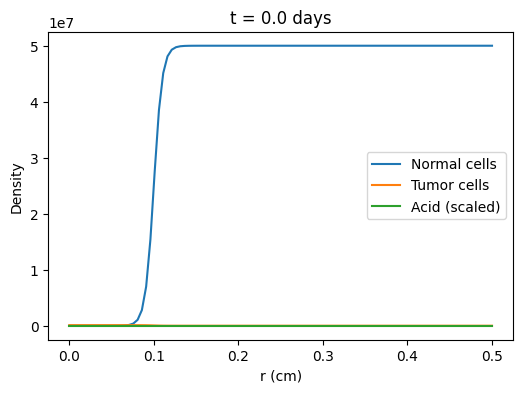

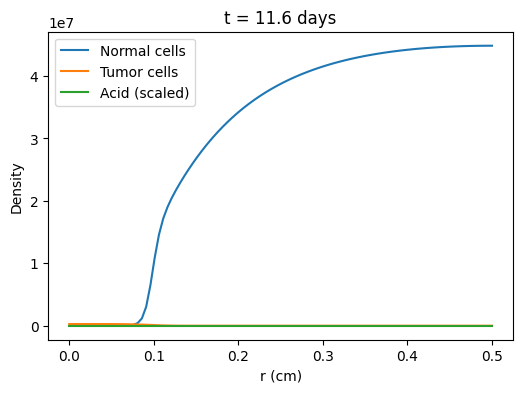

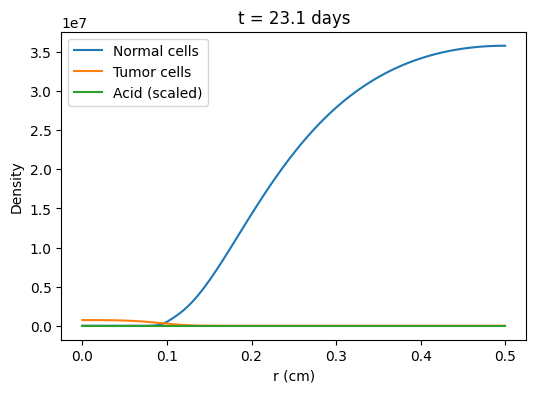

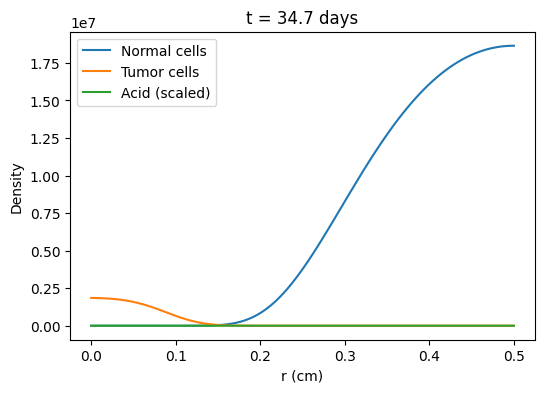

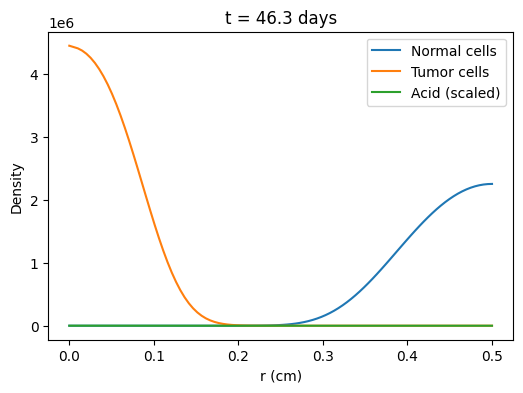

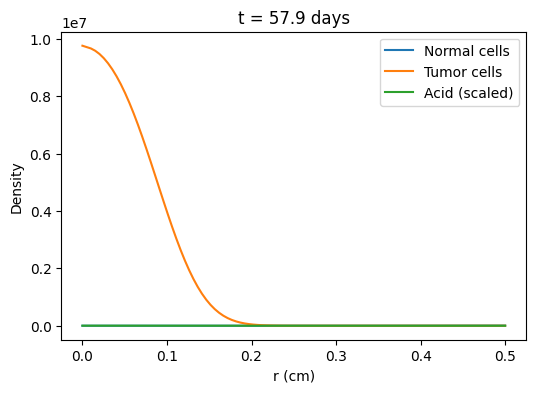

In [8]:
results = sol.y

for i, t in enumerate(sol.t):
    Nn = results[0:n, i]
    Nt = results[n:2*n, i]
    Ch = results[2*n:3*n, i]

    plt.figure(figsize=(6,4))
    plt.plot(r, Nn, label="Normal cells")
    plt.plot(r, Nt, label="Tumor cells")
    plt.plot(r, Ch * 1e10, label="Acid (scaled)")

    plt.title(f"t = {t/86400:.1f} days")
    plt.xlabel("r (cm)")
    plt.ylabel("Density")
    plt.legend()
    plt.show()


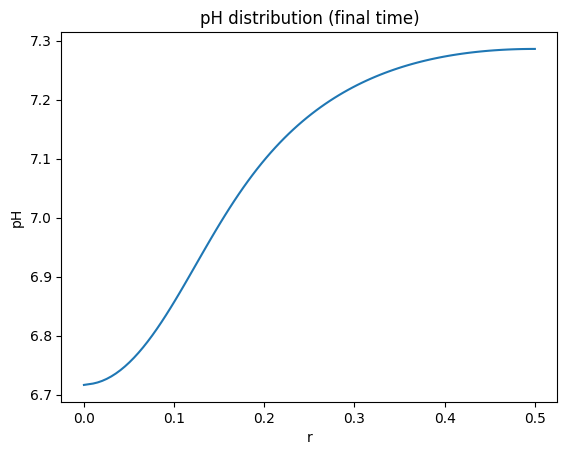

In [9]:
# Convert acid → pH
def compute_pH(Ch):
    return -np.log10(4e-8 + Ch)

pH = compute_pH(results[2*n:3*n, -1])

plt.plot(r, pH)
plt.title("pH distribution (final time)")
plt.xlabel("r")
plt.ylabel("pH")
plt.show()


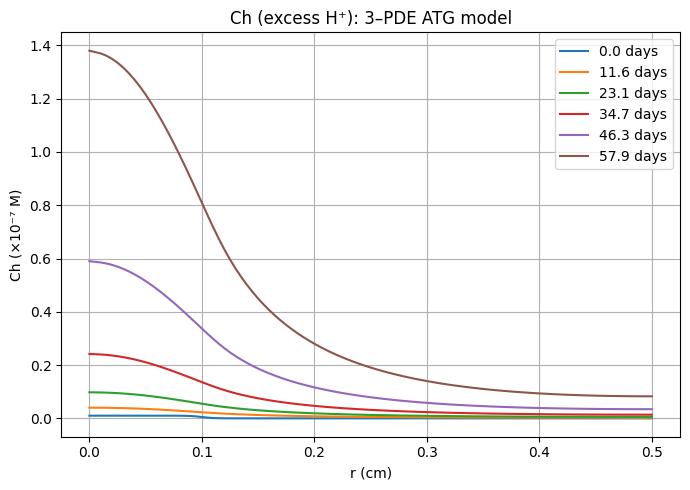

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ----------------------------
# PARAMETERS (EXACT from book)
# ----------------------------
rn = 1e-6
Kn = 5e7

rt = 1e-6
Kt = 5e7
Dt_const = 2e-10

rh = 2.2e-17
dh = 1.1e-4
Dh = 5e-6

# ----------------------------
# SPATIAL DOMAIN
# ----------------------------
r_max = 0.5
n = 101
r = np.linspace(0, r_max, n)
dr = r[1] - r[0]

# ----------------------------
# INITIAL CONDITIONS (CRITICAL)
# ----------------------------
def initial_conditions(r):
    Nn = 5e7 * (1 + np.tanh((r - 0.1)/0.01)) / 2
    Nt = 1e5 * (1 - np.tanh((r - 0.1)/0.01)) / 2
    Ch = 1e-9 * (1 - np.tanh((r - 0.1)/0.01)) / 2
    return Nn, Nt, Ch

Nn0, Nt0, Ch0 = initial_conditions(r)
U0 = np.concatenate([Nn0, Nt0, Ch0])

# ----------------------------
# LAPLACIAN (SPHERICAL)
# ----------------------------
def laplacian(u):
    dudr = np.zeros_like(u)
    d2 = np.zeros_like(u)

    for i in range(1, n-1):
        dudr[i] = (u[i+1] - u[i-1])/(2*dr)
        d2[i] = (u[i+1] - 2*u[i] + u[i-1])/(dr**2)

    # r = 0 symmetry
    d2[0] = 2*(u[1] - u[0])/(dr**2)

    # r = r_max no-flux
    d2[-1] = 2*(u[-2] - u[-1])/(dr**2)

    lap = d2.copy()
    for i in range(1, n-1):
        if r[i] != 0:
            lap[i] += (2/r[i]) * dudr[i]

    return lap

# ----------------------------
# MODEL EQUATIONS (NO SCALING!)
# ----------------------------
def model(t, U):
    Nn = U[0:n]
    Nt = U[n:2*n]
    Ch = U[2*n:3*n]

    Dt = Dt_const * np.maximum(0, (1 - Nn/Kn))

    dNn = rn*Nn*(1 - Nn/Kn) - Ch*Nn
    dNt = rt*Nt*(1 - Nt/Kt) + Dt*laplacian(Nt)
    dCh = rh*Nt - dh*Ch + Dh*laplacian(Ch)

    return np.concatenate([dNn, dNt, dCh])

# ----------------------------
# TIME (EXACT SAME DAYS)
# ----------------------------
days = np.array([0, 11.6, 23.1, 34.7, 46.3, 57.9])
t_eval = days * 86400   # convert to seconds

sol = solve_ivp(
    model,
    (0, t_eval[-1]),
    U0,
    t_eval=t_eval,
    method='BDF',
    rtol=1e-6,
    atol=1e-8
)

# ----------------------------
# PLOT ONLY Ch (MATCH IMAGE)
# ----------------------------
plt.figure(figsize=(7,5))

for i, t in enumerate(days):
    Ch = sol.y[2*n:3*n, i]

    # scale to match axis (×1e-7)
    plt.plot(r, Ch*1e7, label=f"{t:.1f} days")

plt.xlabel("r (cm)")
plt.ylabel("Ch (×10⁻⁷ M)")
plt.title("Ch (excess H⁺): 3–PDE ATG model")

plt.legend()
plt.grid()
plt.tight_layout()
plt.show()